# Utilities

In [25]:
import matplotlib.pyplot as plt
from jupyterthemes import jtplot
import matplotlib as mpl
mpl.rcdefaults() 
import scipy.stats as st
from scipy.stats import binom
import xarray as xr
from scipy.stats import linregress
from EWS_functions import *
from EWS_wrappers import *

jtplot.style(context='paper', fscale=1.4, spines=True, grid=False, ticks=True,gridlines='--')

fontsize=16
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['figure.titlesize'] = 'medium'
mpl.rcParams['axes.labelsize']= 'x-large'
mpl.rcParams['figure.facecolor']='white'
mpl.rcParams['text.latex.preamble']= r'\usepackage{amsmath}'
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']) 


In [26]:
# DATA PATHS
# ----------
# Set these to the directories where your large data files are stored.
# These files are too large to include in the repository.
# EWS_DIR  : directory containing the computed EWS arrays (lambdas, AR1s, stds)
#             for all CMIP6 models. Relative path from this notebook's location.
# OBS_DIR  : directory containing the ERSSTv5 observational ensemble data.
EWS_DIR = '../../new_AR6'
OBS_DIR = '/p/tmp/mayayami/sst-uncertainties-data/ERSSTv5'


In [27]:
labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)']


In [28]:
# function to get the percentile of the last value in an array, ignoring nans
# applies 
def f(x):
    if not np.isnan(x[-1]):
        x=x[~np.isnan(x)]
        return st.percentileofscore(x, x[-1])
    else:
        return np.nan


In [29]:
def get_corr(x,y):
    y = y[~np.isnan(x)]
    x = x[~np.isnan(x)]
    slope, intercept, r, p, se = linregress(x,y)
    return r, p


In [30]:
def get_pvs(true_trends,surr_trends,dim='surrogates'):
    d = true_trends.expand_dims(dim=dim, axis=0)
    d[dim]=[int(len(surr_trends[dim].values))]
    parr = xr.concat((surr_trends,d),dim=dim) # the last value on the row is the true trend
    ppvs = 1- np.apply_along_axis(f, 3, parr)/100
    return ppvs


# data

## AMOC timeseries

In [31]:
ds = xr.open_dataset('CMIP6_amoc2.nc').amoc
strn26 = ds.sel(indices='strn26')
strn35 = ds.sel(indices='strn35')
index = ds.sel(indices='index')
yrs = strn26.time.values
models = strn26.models.values
ensembs = strn26.ensemble_members.values


In [32]:
model_names = []
for mod in models:
    n_tot = np.count_nonzero(~np.isnan(strn35.sel(models=mod).values))
    if n_tot!=0:
        model_names.append(mod)


## AMOC trends

In [33]:
# ERSSTv5 operational product trend
Eamocy = xr.open_dataset(f'{OBS_DIR}/sst.mnmean.1854.2017_ymean_amoc.nc').sst.squeeze()[:-3]
slope, intercept, r, p, se = linregress(np.arange(1854,2015),Eamocy.values)
o_trend = slope*100

# ERSSTv5 ensemble trends
Eamocsy = xr.open_dataset(f'{OBS_DIR}/sst2d.ano.1854.2017.ensemble_amoc_full_ymean.nc').sst[:-3]
Eamocsy['time']=np.arange(1854,2015)
Eamocsy_trends = Eamocsy.polyfit(dim = 'time', deg = 1).polyfit_coefficients.sel(degree=1)*100


In [34]:
strn26_trend = np.zeros((34,10))
for imod in range(34):
    for iens in range(10):
        amc = np.nan_to_num(strn26.values[imod,iens,:])
        slope, intercept, r, p, se = linregress(yrs, amc)
        strn26_trend[imod,iens]=slope*100 # trend of Sv/century
index_trend = np.zeros((34,10))
for imod in range(34):
    for iens in range(10):
        idx = np.nan_to_num(index.values[imod,iens,:])
        slope, intercept, r, p, se = linregress(yrs, idx)
        index_trend[imod,iens]=slope*100 # trend of Sv/century
strn35_trend = np.zeros((34,10))
for imod in range(34):
    for iens in range(10):
        amc = np.nan_to_num(strn35.values[imod,iens,:])
        slope, intercept, r, p, se = linregress(yrs, amc)
        strn35_trend[imod,iens]=slope*100 # trend of Sv/century


## rolling decadal correlations

In [35]:
dec_model26_corr = xr.corr(index.rolling(time=10).mean(),strn26.rolling(time=10).mean(),dim='time')
dec_model35_corr = xr.corr(index.rolling(time=10).mean(),strn35.rolling(time=10).mean(),dim='time')


In [36]:
# calculate percentage of members with decadal correlation above 0.5
print(int(np.where(dec_model26_corr>=0.5)[0].shape[0])/133)
print(int(np.where(dec_model35_corr>=0.5)[0].shape[0])/133)


0.556390977443609
0.48872180451127817


## EWS p-values

In [37]:
cmip_trends = xr.open_dataset(f'{EWS_DIR}/CMIP6_lambdas_w60_rmean_trends.nc').polyfit_coefficients.sel(degree=1)


In [38]:
all_EWS = xr.open_dataset('CMIP6_all_EWS_ppvs.nc')
ar1_ppvs = all_EWS.ppvs.sel(indicators='ar1')
std_ppvs = all_EWS.ppvs.sel(indicators='var')
ppvs = all_EWS.ppvs.sel(indicators='lambda')



# Figure 1

In [39]:
Eamocsy = xr.open_dataset(f'{OBS_DIR}/sst2d.ano.1854.2017.ensemble_amoc_full_ymean.nc').sst
Eamocy = xr.open_dataset(f'{OBS_DIR}/sst.mnmean.1854.2017_ymean_amoc.nc').sst.squeeze()
Elam = lambda_wrapper_rmean(Eamocy,ws=60)[30:-30]


In [40]:
def remove(ax):
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.spines.left.set_visible(False)
    ax.spines.bottom.set_visible(False)
    ax.yaxis.set_ticks_position('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_ticks_position('none')
    ax.set_xticklabels([])
    ax.set_yticklabels([])


In [41]:
def plot_trend(ax,xx,yy,cl):
    slope, intercept, r, p, se = linregress(xx, yy)
    ax.plot(xx,intercept+xx*slope,color=cl,alpha=0.5,linestyle='--')


In [42]:
lambdas = xr.open_dataset(f'{EWS_DIR}/CMIP6_lambdas_w60_rmean.nc').amoc

s1=lambdas.sel(indices='strn26',models='CanESM5').isel(ensemble_members=9).values[30:-30]
i1= lambdas.sel(indices='index',models='CanESM5').isel(ensemble_members=9).values[30:-30]

s2=lambdas.sel(indices='strn26',models='CanESM5').isel(ensemble_members=7).values[30:-30]
i2= lambdas.sel(indices='index',models='CanESM5').isel(ensemble_members=7).values[30:-30]

s3=lambdas.sel(indices='strn26',models='GISS-E2-1-G').isel(ensemble_members=2).values[30:-30]
i3= lambdas.sel(indices='index',models='GISS-E2-1-G').isel(ensemble_members=2).values[30:-30]

s4=lambdas.sel(indices='strn26',models='GISS-E2-1-G').isel(ensemble_members=8).values[30:-30]
i4= lambdas.sel(indices='index',models='GISS-E2-1-G').isel(ensemble_members=8).values[30:-30]


<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3207289/433876984.py:33: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('Real AMOC $\lambda$')
/tmp/ipykernel_3207289/433876984.py:36: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel('Real SST $\lambda$')
/tmp/ipykernel_3207289/433876984.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax3.set_ylabel('Model AMOC $\lambda$')
/tmp/ipykernel_3207289/433876984.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax4.set_ylabel('Model SST $\lambda$')


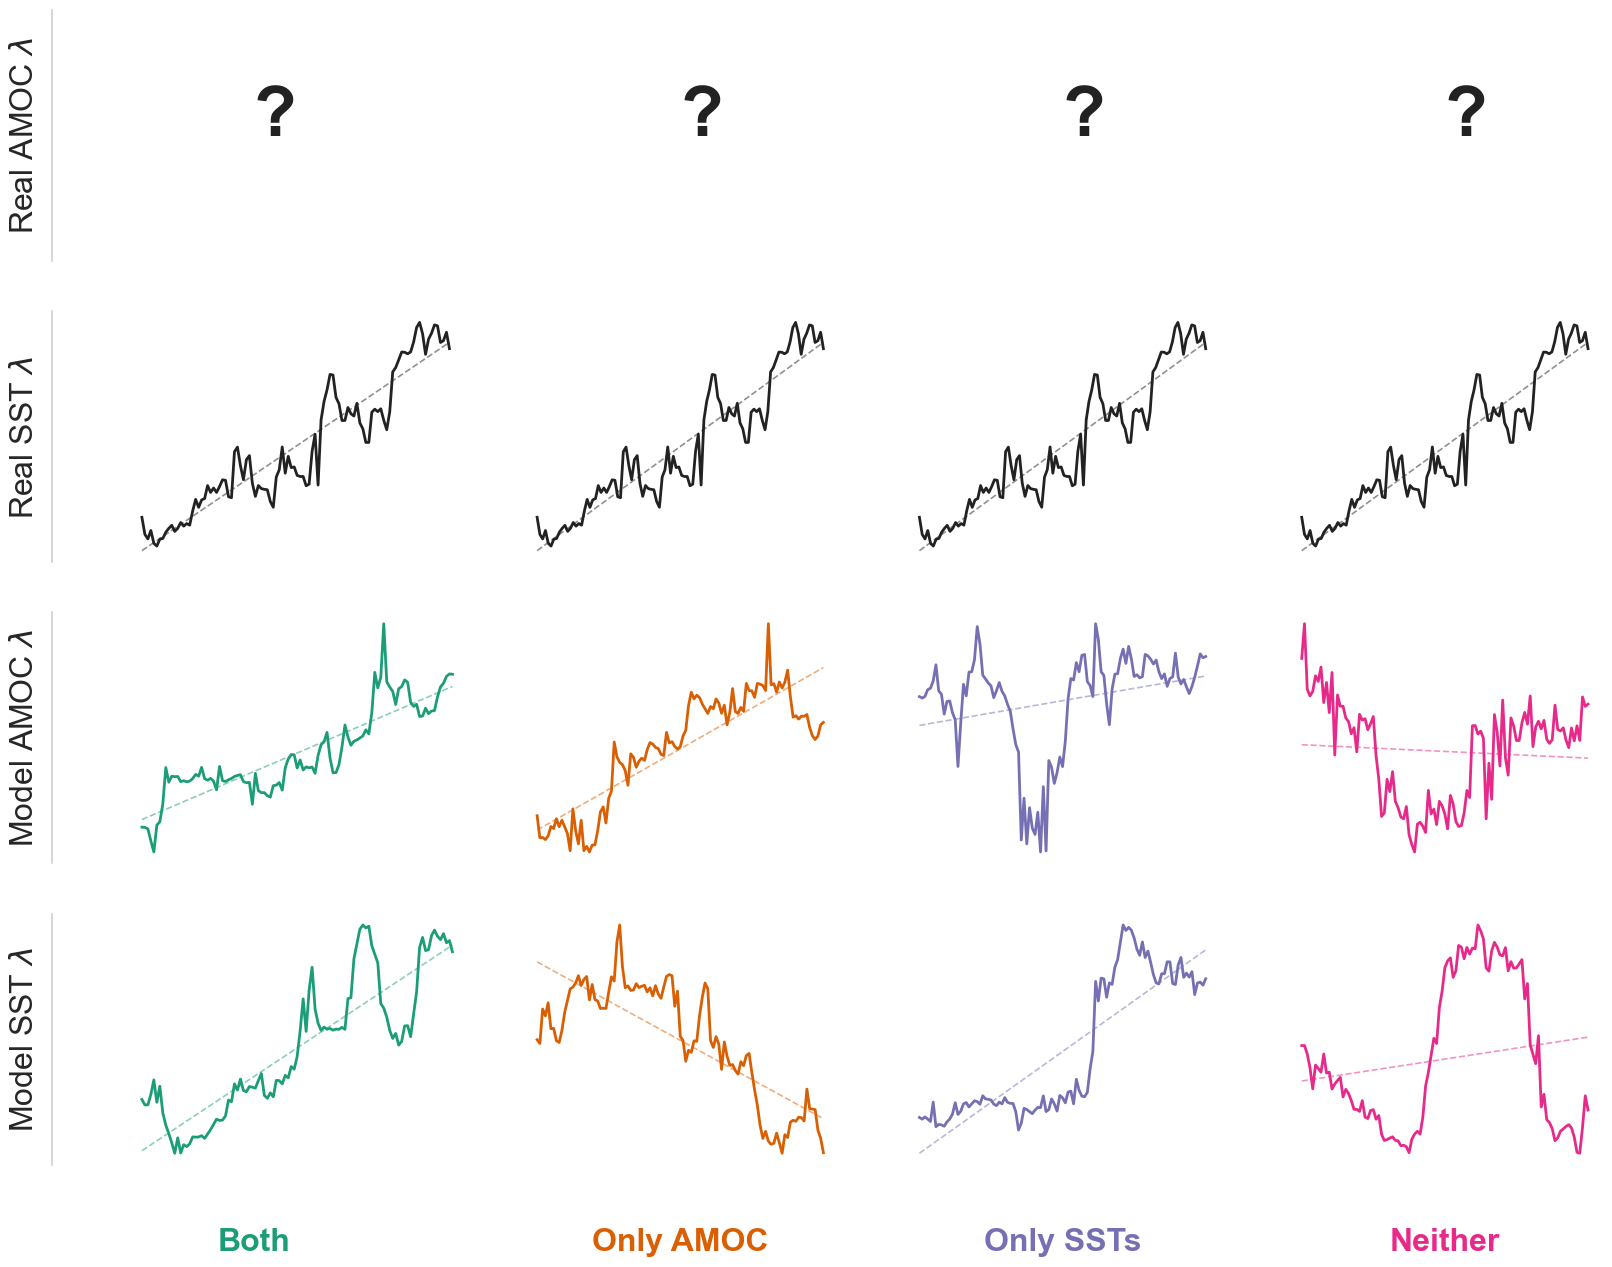

In [43]:
fig = plt.figure(figsize=(20,15))
gs = fig.add_gridspec(nrows=4, ncols=4,width_ratios=(1.28,1,1,1))

ss = [s1,s2,s3,s4]
ii = [i1,i2,i3,i4]
cls = ['C0','C1','C2','C3']
lbls = ['Both','Only AMOC','Only SSTs','Neither']
xx = np.arange(0,105)

for i in range(4):
    ax1 = fig.add_subplot(gs[0,i])
    remove(ax1)
    ax1.text(0.5,0.5,'?',transform=ax1.transAxes,fontweight='bold',ma='left',color='k',fontsize=50)
    ax2 = fig.add_subplot(gs[1,i])
    remove(ax2)
    ax2.plot(xx[:-1],Elam,lw=2,color='k')
    plot_trend(ax2,xx[:-1],Elam,'k')
    
    ax3 = fig.add_subplot(gs[2,i])
    remove(ax3)
    ax3.plot(xx,ss[i],lw=2,color=cls[i])
    plot_trend(ax3,xx,ss[i],cls[i])  
    
    ax4 = fig.add_subplot(gs[3,i])
    remove(ax4)
    ax4.plot(xx,ii[i],lw=2,color=cls[i])
    plot_trend(ax4,xx,ii[i],cls[i])  

    ax4.set_xlabel(lbls[i],color=cls[i],fontweight='bold',labelpad=40)
    
    if i==0:
        ax1.spines.left.set_visible(True)
        ax1.set_ylabel('Real AMOC $\lambda$')
        
        ax2.spines.left.set_visible(True)
        ax2.set_ylabel('Real SST $\lambda$') 
        ax2.set_xlim(-30,105)
        
        ax3.spines.left.set_visible(True)
        ax3.set_ylabel('Model AMOC $\lambda$')  
        ax3.set_xlim(-30,105)

        ax4.spines.left.set_visible(True)
        ax4.set_ylabel('Model SST $\lambda$')
        ax4.set_xlim(-30,105)

plt.show()


# Figure 2

In [44]:
slope, intercept, r1, p, se = linregress(index_trend.flatten(), strn26_trend.flatten())
slope, intercept, r2, p, se = linregress(index_trend.flatten(), strn35_trend.flatten())


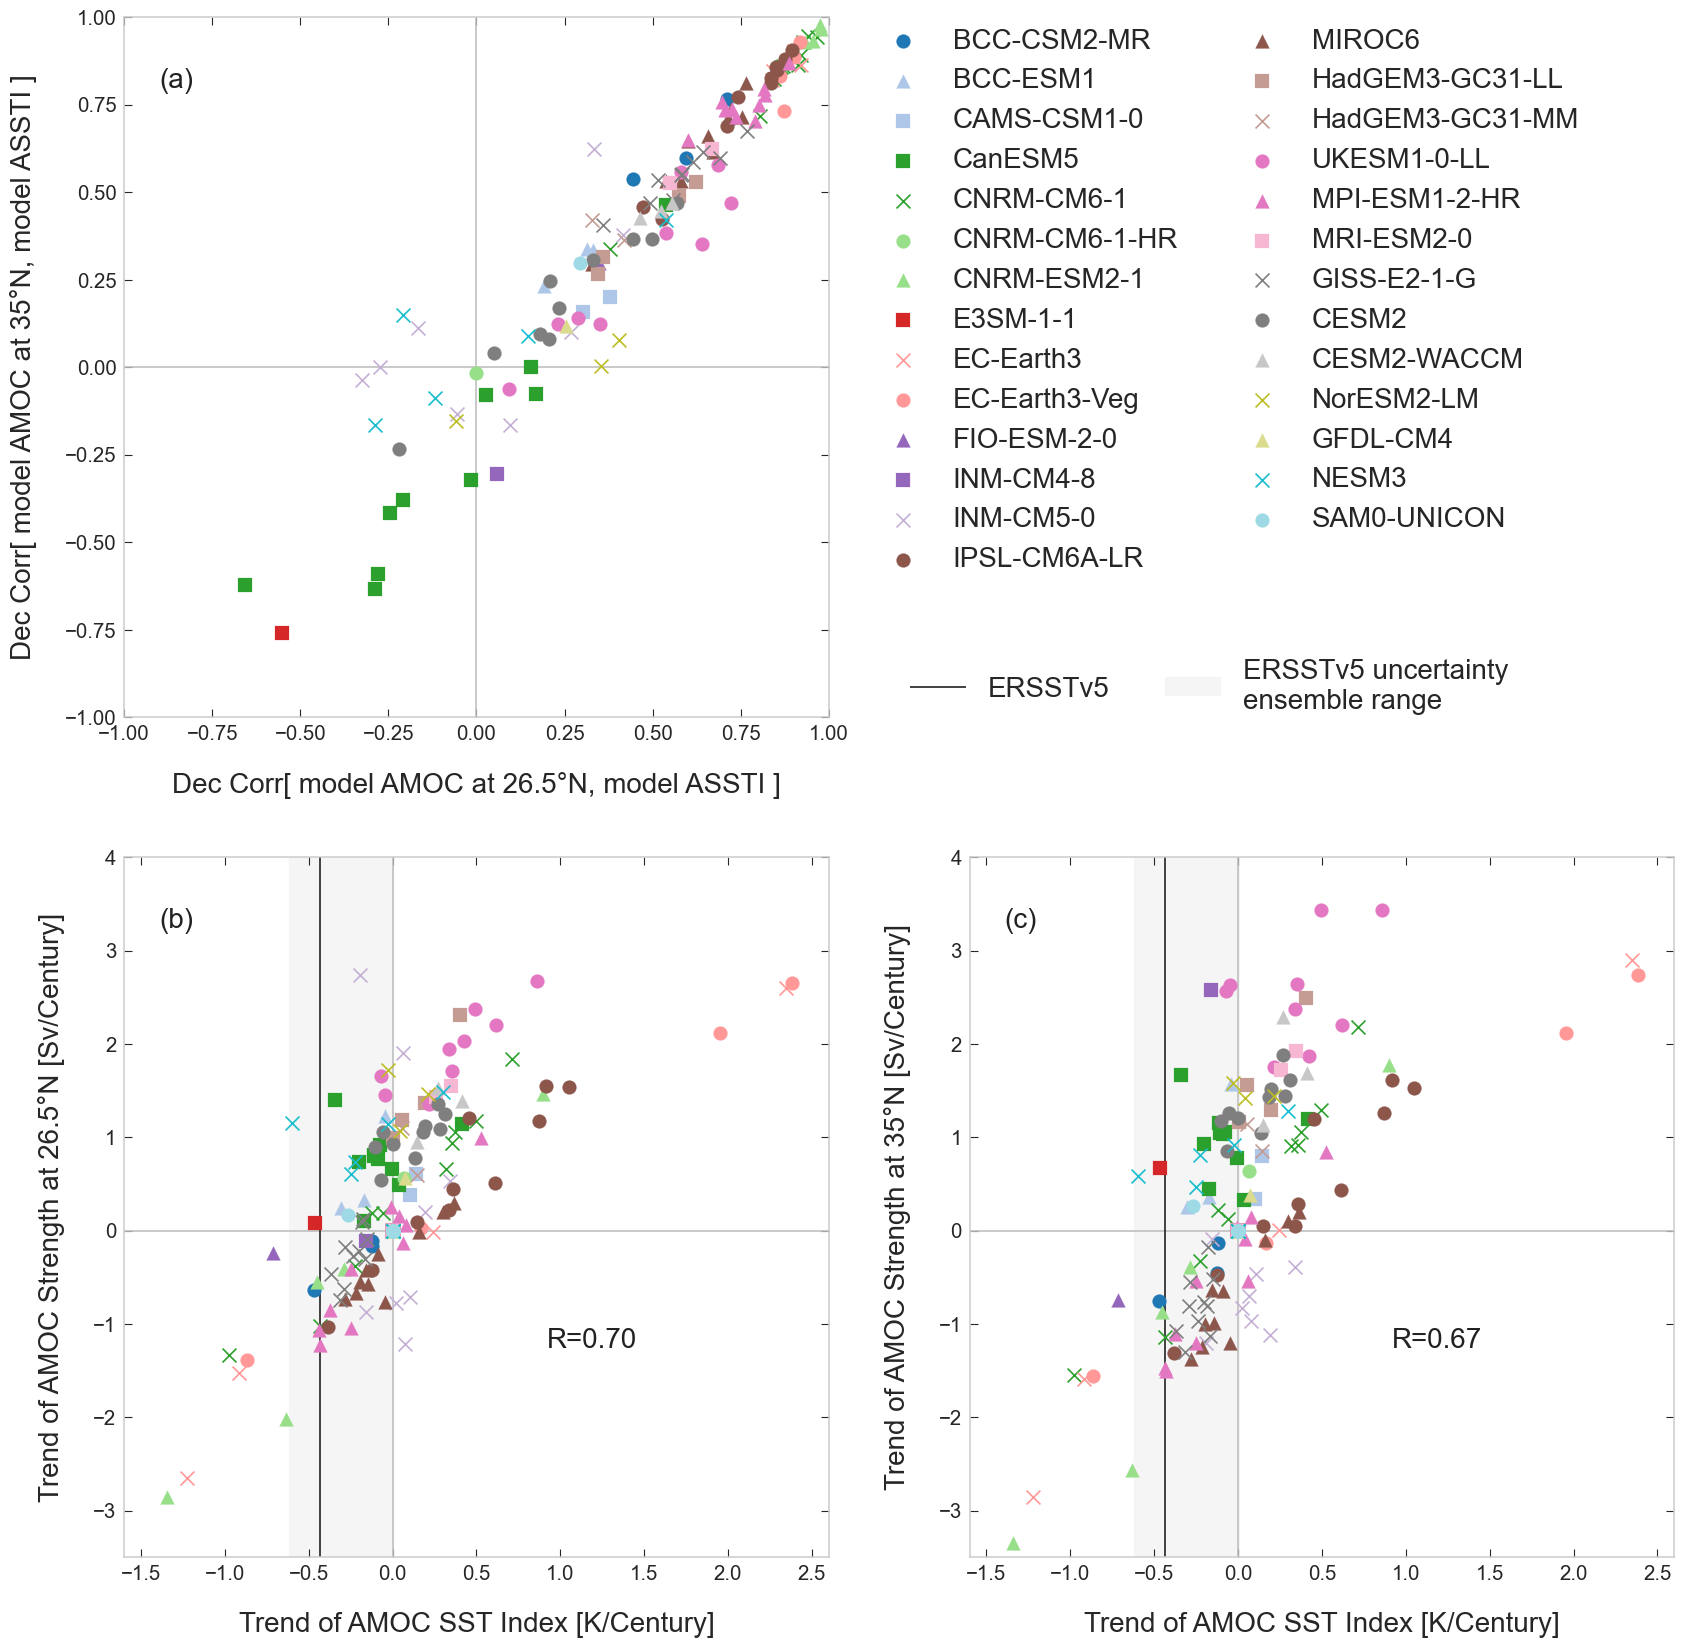

In [45]:
cmap = plt.get_cmap('tab20')
color_list = [cmap(i/34) for i in np.arange(0,34)]
markers = ['x','o','^','s']

fig = plt.figure(figsize=(20,20))

gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])

for i, mod in enumerate(models):
    n_tot = np.count_nonzero(~np.isnan(strn35.sel(models=mod).values))
    if n_tot!=0:
        marker = markers[i%4]
        col = color_list[i]
        ax1.scatter(dec_model26_corr[i],dec_model35_corr[i],color=col,label=mod,marker=marker,s=100,zorder=20)
        ax2.scatter(index_trend[i],strn26_trend[i],color=col,label=mod,marker=marker,s=100,zorder=20)
        ax3.scatter(index_trend[i],strn35_trend[i],color=col,marker=marker,s=100,zorder=20)
        
        
xx = np.linspace(-2,3,100)
ax2.set_ylim(-3.5,4)
ax2.set_xlim(-1.6,2.6)
ax2.hlines(0,-10,10,color='silver',alpha=1)
ax2.vlines(0,-10,10,color='silver',alpha=1)
ax2.vlines(o_trend,-10,10,color='k',label='ERSSTv5')
ax2.fill_betweenx([-10,10],Eamocsy_trends.min(dim='member'),Eamocsy_trends.max(dim='member'),color='whitesmoke',alpha=1, label='Range of ERSSTv5\nuncertainty ensemble',zorder=0)
ax2.set_xlabel('Trend of AMOC SST Index [K/Century]',fontsize=20,labelpad=20)
ax2.set_ylabel('Trend of AMOC Strength at 26.5°N [Sv/Century]',fontsize=20,labelpad=20,x=0.01)
ax2.text(0.05,0.9,labels[1],transform=ax2.transAxes,color='k',fontsize=20)
ax2.text(0.6,0.3,'R={:.2f}'.format(r1),transform=ax2.transAxes,color='k',fontsize=20)

xx = np.linspace(-2,3,100)
ax3.set_ylim(-3.5,4)
ax3.set_xlim(-1.6,2.6)
ax3.hlines(0,-10,10,color='silver',alpha=1)
ax3.vlines(0,-10,10,color='silver',alpha=1)
ax3.vlines(o_trend,-10,10,color='k',label='ERSSTv5')
ax3.fill_betweenx([-10,10],Eamocsy_trends.min(dim='member'),Eamocsy_trends.max(dim='member'),color='whitesmoke',alpha=1, label='ERSSTv5 uncertainty\nensemble range',zorder=0)
ax3.text(0.05,0.9,labels[2],transform=ax3.transAxes,color='k',fontsize=20)
ax3.text(0.6,0.3,'R={:.2f}'.format(r2),transform=ax3.transAxes,color='k',fontsize=20)
ax3.set_xlabel('Trend of AMOC SST Index [K/Century]',fontsize=20,labelpad=20)
ax3.set_ylabel('Trend of AMOC Strength at 35°N [Sv/Century]',fontsize=20,labelpad=20,x=0.01)


ax1.set_ylim(-1,1)
ax1.set_xlim(-1,1)
ax1.hlines(0,-1,1,color='silver',alpha=1)
ax1.vlines(0,-1,1,color='silver',alpha=1)
ax1.text(0.05,0.9,labels[0],transform=ax1.transAxes,color='k',fontsize=20)
ax3.legend(bbox_to_anchor=(-.1, 1.3), loc='upper left', borderaxespad=0., fontsize=20,fancybox=False,frameon=False,ncol=2)

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20,fancybox=False,frameon=False,ncol=2)
ax1.set_ylabel('Dec Corr[ model AMOC at 35°N, model ASSTI ]',labelpad=20,fontsize=20)
ax1.set_xlabel('Dec Corr[ model AMOC at 26.5°N, model ASSTI ]',labelpad=20,fontsize=20)
plt.show()


# Figure 3

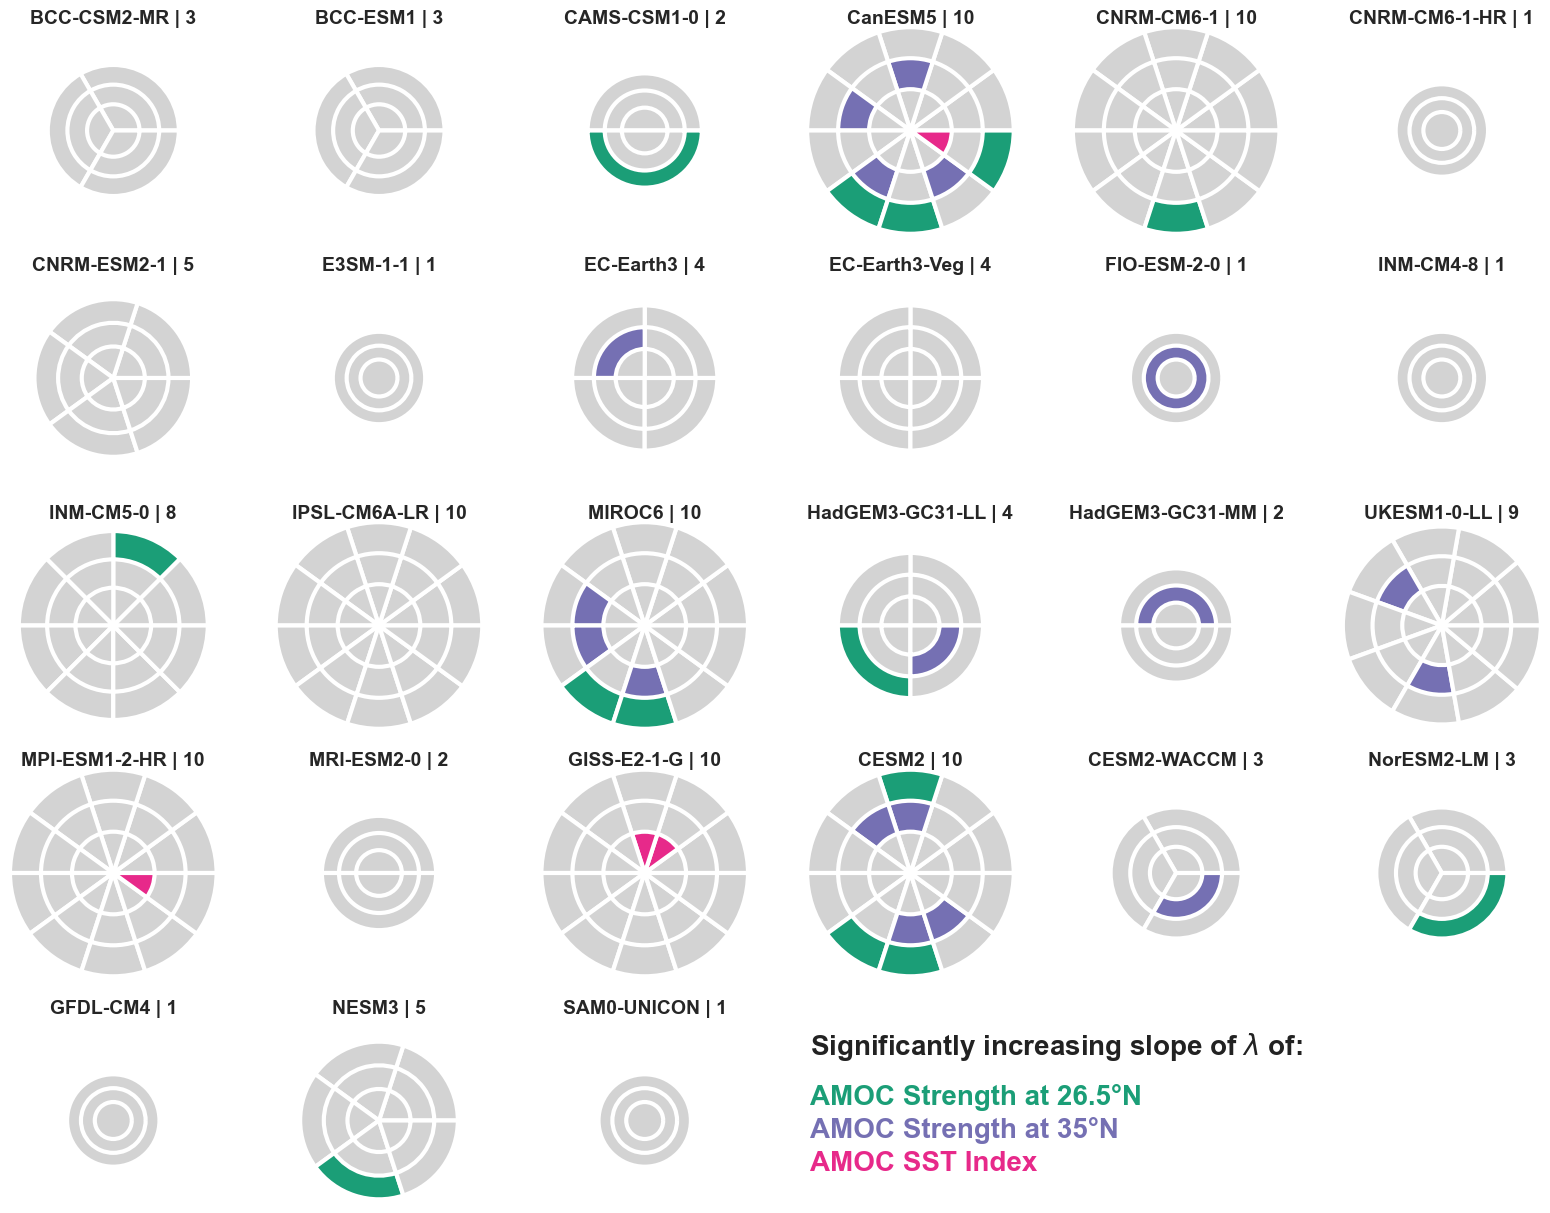

In [46]:
radius_one = 0.3
# for modls in [models[0:12],models[12:22],models[22:]]:
fig = plt.figure(figsize=(20,15))
gs = fig.add_gridspec(5, 6)
ir = 0
x = 0
for im, model in enumerate(models):
    idc = np.where(~np.isnan(cmip_trends.sel(indices='strn26').sel(models=model).values))
    n_tot = np.count_nonzero(~np.isnan(cmip_trends.sel(indices='strn26').sel(models=model).values))

    radius = 0.3+0.4*np.sqrt(n_tot)

    if n_tot!= 0:
        if ir<=5:
            ax = fig.add_subplot(gs[0,ir])
        if (ir>=6) & (ir<=11):
            ax = fig.add_subplot(gs[1,ir-6])
        if (ir>=12) & (ir<=17):
            ax = fig.add_subplot(gs[2,ir-12])
        if (ir>=18) & (ir<=23):
            ax = fig.add_subplot(gs[3,ir-18])
        if (ir>=24):
            ax = fig.add_subplot(gs[4,ir-24])

        ax.set_title('{} | {}'.format(model,n_tot),fontsize=14,fontweight='bold',y=1.1)
        
        colorss = ['C0','C2','C3']
        rads = [1,0.7,0.4]
        
        for i in range(3):
            data = ppvs[i][im][idc]
            slices = np.full(len(data),1)
            x = x+ len(slices)
            idc2 = np.where(data<=0.05)
            cols = np.full(len(data),'lightgrey')
            cols[idc2] = colorss[i]
            patches, texts= ax.pie(
            slices,
                radius = rads[i]*radius,
            colors = cols,
            wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},
            textprops={'size': 'x-large'})

        ir = ir +1
        
        if ir==27:
            ax.text(1.5,0.9,r'Significantly increasing slope of $\lambda$ of:',transform=ax.transAxes,fontweight='bold',ma='left',color='k',fontsize=20)
            ax.text(1.5,0.6,'AMOC Strength at 26.5°N',transform=ax.transAxes,fontweight='bold',ma='left',color='C0',fontsize=20)
            ax.text(1.5,0.4,'AMOC Strength at 35°N',transform=ax.transAxes,fontweight='bold',ma='left',color='C2',fontsize=20)
            ax.text(1.5,0.2,'AMOC SST Index',transform=ax.transAxes,fontweight='bold',ma='left',color='C3',fontsize=20)
fig.subplots_adjust(hspace=0.5)
fig.patch.set_facecolor("white")
plt.show()


# Figure 4

In [47]:
# create a new array with the same shape as ppvs, where the value is 3 if all three CSD indicators have <=0.05, 2 if two of them are <=0.05, 1 if one of them is <=0.05, and 0 if none of them are <=0.05

counts = np.full(ppvs.shape,np.nan)
counts[np.where((ar1_ppvs<=0.05)&(std_ppvs<=0.05)&(ppvs<=0.05))]=3
counts[np.where(
    ((ar1_ppvs<=0.05)&(std_ppvs<=0.05)&(ppvs>0.05)) |
   ((ar1_ppvs<=0.05)&(std_ppvs>0.05)&(ppvs<=0.05)) |
    ((ar1_ppvs>0.05)&(std_ppvs<=0.05)&(ppvs<=0.05)))       
      ]=2
counts[np.where(
    ((ar1_ppvs<=0.05)&(std_ppvs>0.05)&(ppvs>0.05)) |
   ((ar1_ppvs>0.05)&(std_ppvs>0.05)&(ppvs<=0.05)) |
    ((ar1_ppvs>0.05)&(std_ppvs<=0.05)&(ppvs>0.05)))       
      ]=1


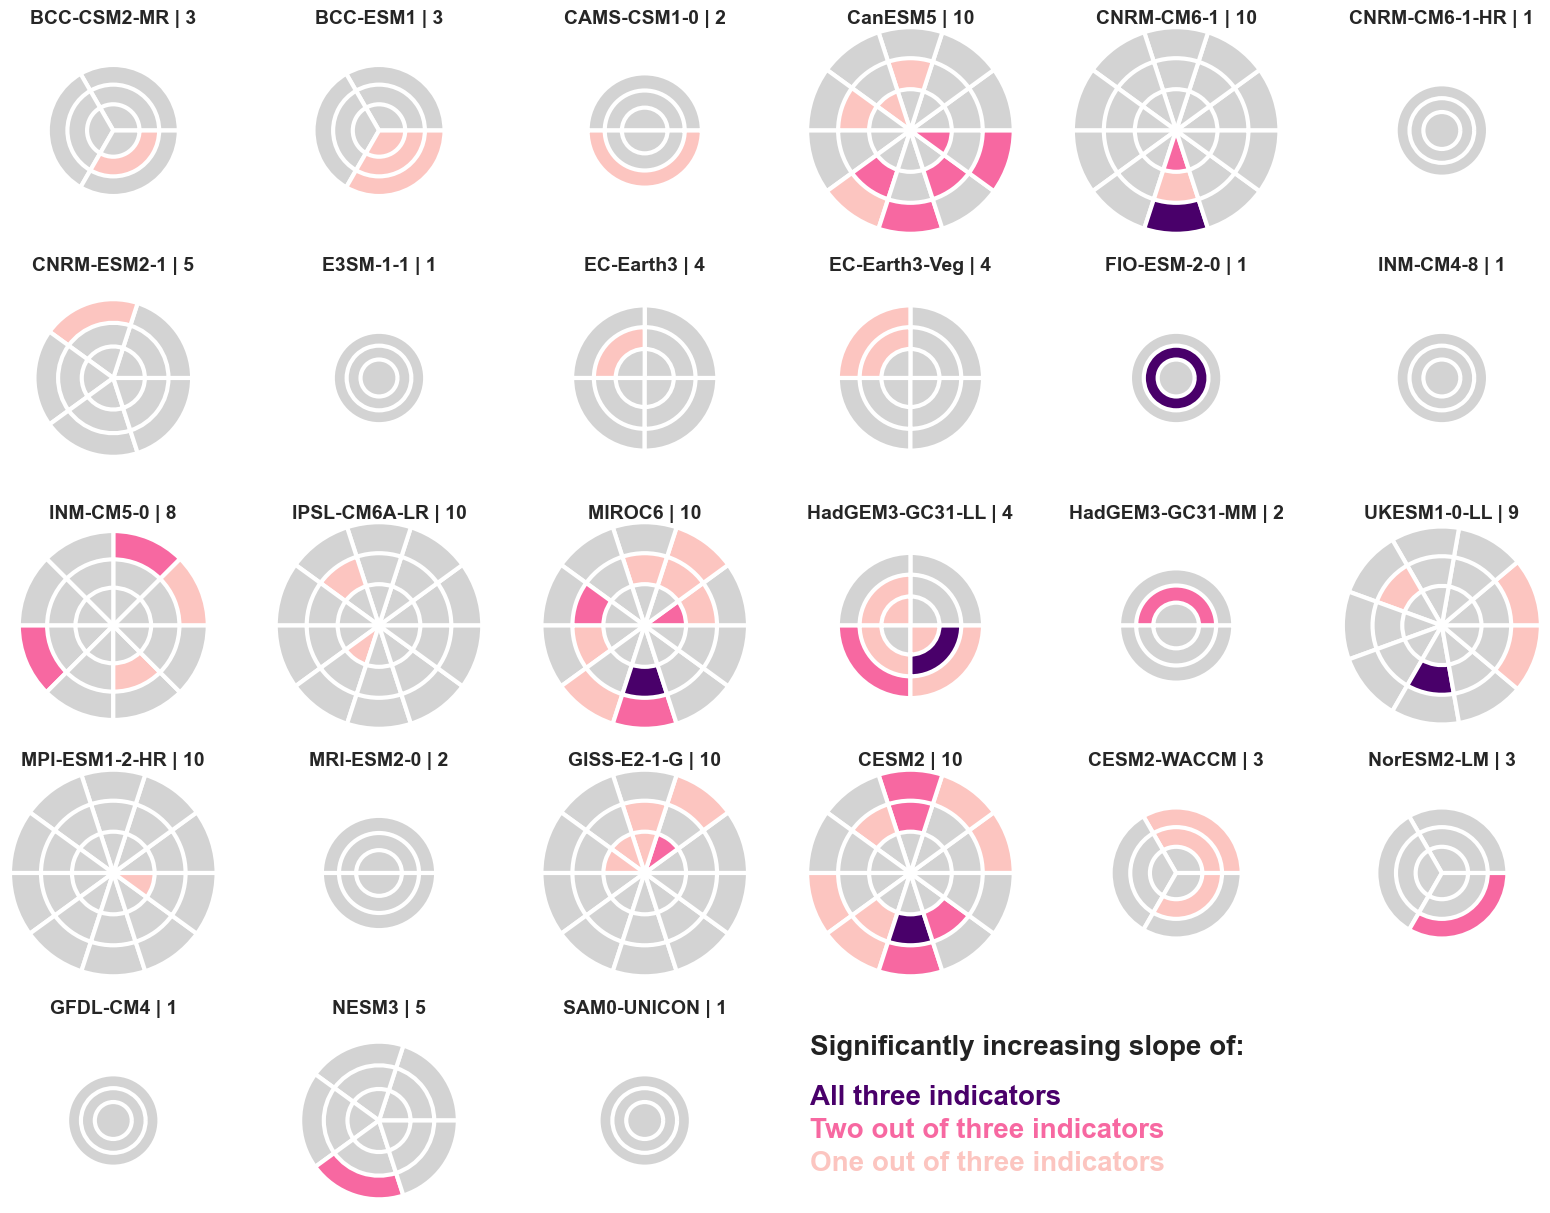

In [48]:
radius_one = 0.3
fig = plt.figure(figsize=(20,15))
gs = fig.add_gridspec(5, 6)
ir = 0
x = 0
for im, model in enumerate(models):
    idc = np.where(~np.isnan(cmip_trends.sel(indices='strn26').sel(models=model).values))
    n_tot = np.count_nonzero(~np.isnan(cmip_trends.sel(indices='strn26').sel(models=model).values))

    radius = 0.3+0.4*np.sqrt(n_tot)

    if n_tot!= 0:
        if ir<=5:
            ax = fig.add_subplot(gs[0,ir])
        if (ir>=6) & (ir<=11):
            ax = fig.add_subplot(gs[1,ir-6])
        if (ir>=12) & (ir<=17):
            ax = fig.add_subplot(gs[2,ir-12])
        if (ir>=18) & (ir<=23):
            ax = fig.add_subplot(gs[3,ir-18])
        if (ir>=24):
            ax = fig.add_subplot(gs[4,ir-24])

        ax.set_title('{} | {}'.format(model,n_tot),fontsize=14,fontweight='bold',y=1.1)
        
        colorss = ['C0','C2','C3']
        colorss = ['#49006a','#f768a1','#fcc5c0'][::-1]
        rads = [1,0.7,0.4]
        
        for i in range(3):
            data = counts[i][im][idc]
            slices = np.full(len(data),1)
            x = x+ len(slices)
            idc2 = np.where(data<=0.05)
            cols = np.full(len(data),'lightgrey')
            for j in range(len(data)):
                if data[j]>0:
                    cols[j] = colorss[int(data[j])-1]
            patches, texts= ax.pie(
            slices,
                radius = rads[i]*radius,
            colors = cols,
            wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},
            textprops={'size': 'x-large'})

        ir = ir +1
        
        if ir==27:
            ax.text(1.5,0.9,'Significantly increasing slope of:',transform=ax.transAxes,fontweight='bold',ma='left',color='k',fontsize=20)
            ax.text(1.5,0.6,'All three indicators',transform=ax.transAxes,fontweight='bold',ma='left',color=colorss[2],fontsize=20)
            ax.text(1.5,0.4,'Two out of three indicators',transform=ax.transAxes,fontweight='bold',ma='left',color=colorss[1],fontsize=20)
            ax.text(1.5,0.2,'One out of three indicators',transform=ax.transAxes,fontweight='bold',ma='left',color=colorss[0],fontsize=20)
fig.subplots_adjust(hspace=0.5)
fig.patch.set_facecolor("white")
plt.show()


# Figure 5

nine sets of 133 time series, expected value of something with p=0.05 is 6.65

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3207289/2509857222.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Number of ensemble members with p$\leq$0.05\nindicator trend (out of 133)',fontsize=15)


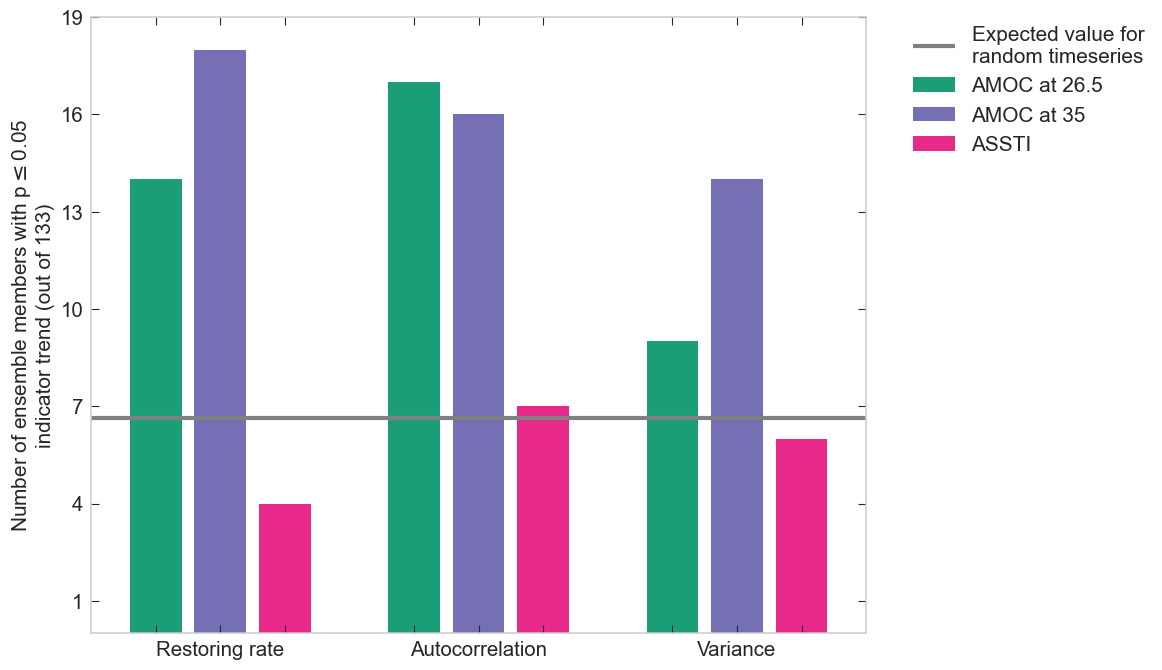

In [49]:
fig = plt.figure(figsize=(10,8))
gs = fig.add_gridspec(1, 1)
ax = fig.add_subplot(gs[0,0])
cls = ['C0','C2','C3']
lbls = ['AMOC at 26.5','AMOC at 35','ASSTI']
ilbls = ['Restoring rate','Autocorrelation','Variance']
ib = 0 
for j, indc in enumerate(['lambda','ar1','var']):
    for i, idx in enumerate(['strn26','strn35','index']):
        dd = all_EWS.ppvs.sel(indicators=indc).sel(indices=idx)
        ews_tot = len(np.where(dd<=0.05)[0])
        if j==0:
            ax.bar(ib+j, ews_tot,color=cls[i],label=lbls[i])
        else:
            ax.bar(ib+j, ews_tot,color=cls[i])
        ib += 1
ax.hlines(6.65,-2,13,color='grey',lw=3,alpha=1,label='Expected value for\nrandom timeseries')
ax.set_xlim(-1,11)
ax.set_xticks([0,1,2,4,5,6,8,9,10])
ax.set_xticklabels(['','Restoring rate','','','Autocorrelation','','','Variance',''])
ax.set_yticks(np.arange(1,20,3))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15,fancybox=False,frameon=False,ncol=1)
ax.set_ylabel('Number of ensemble members with p$\leq$0.05\nindicator trend (out of 133)',fontsize=15)
plt.show()


# Figure 6

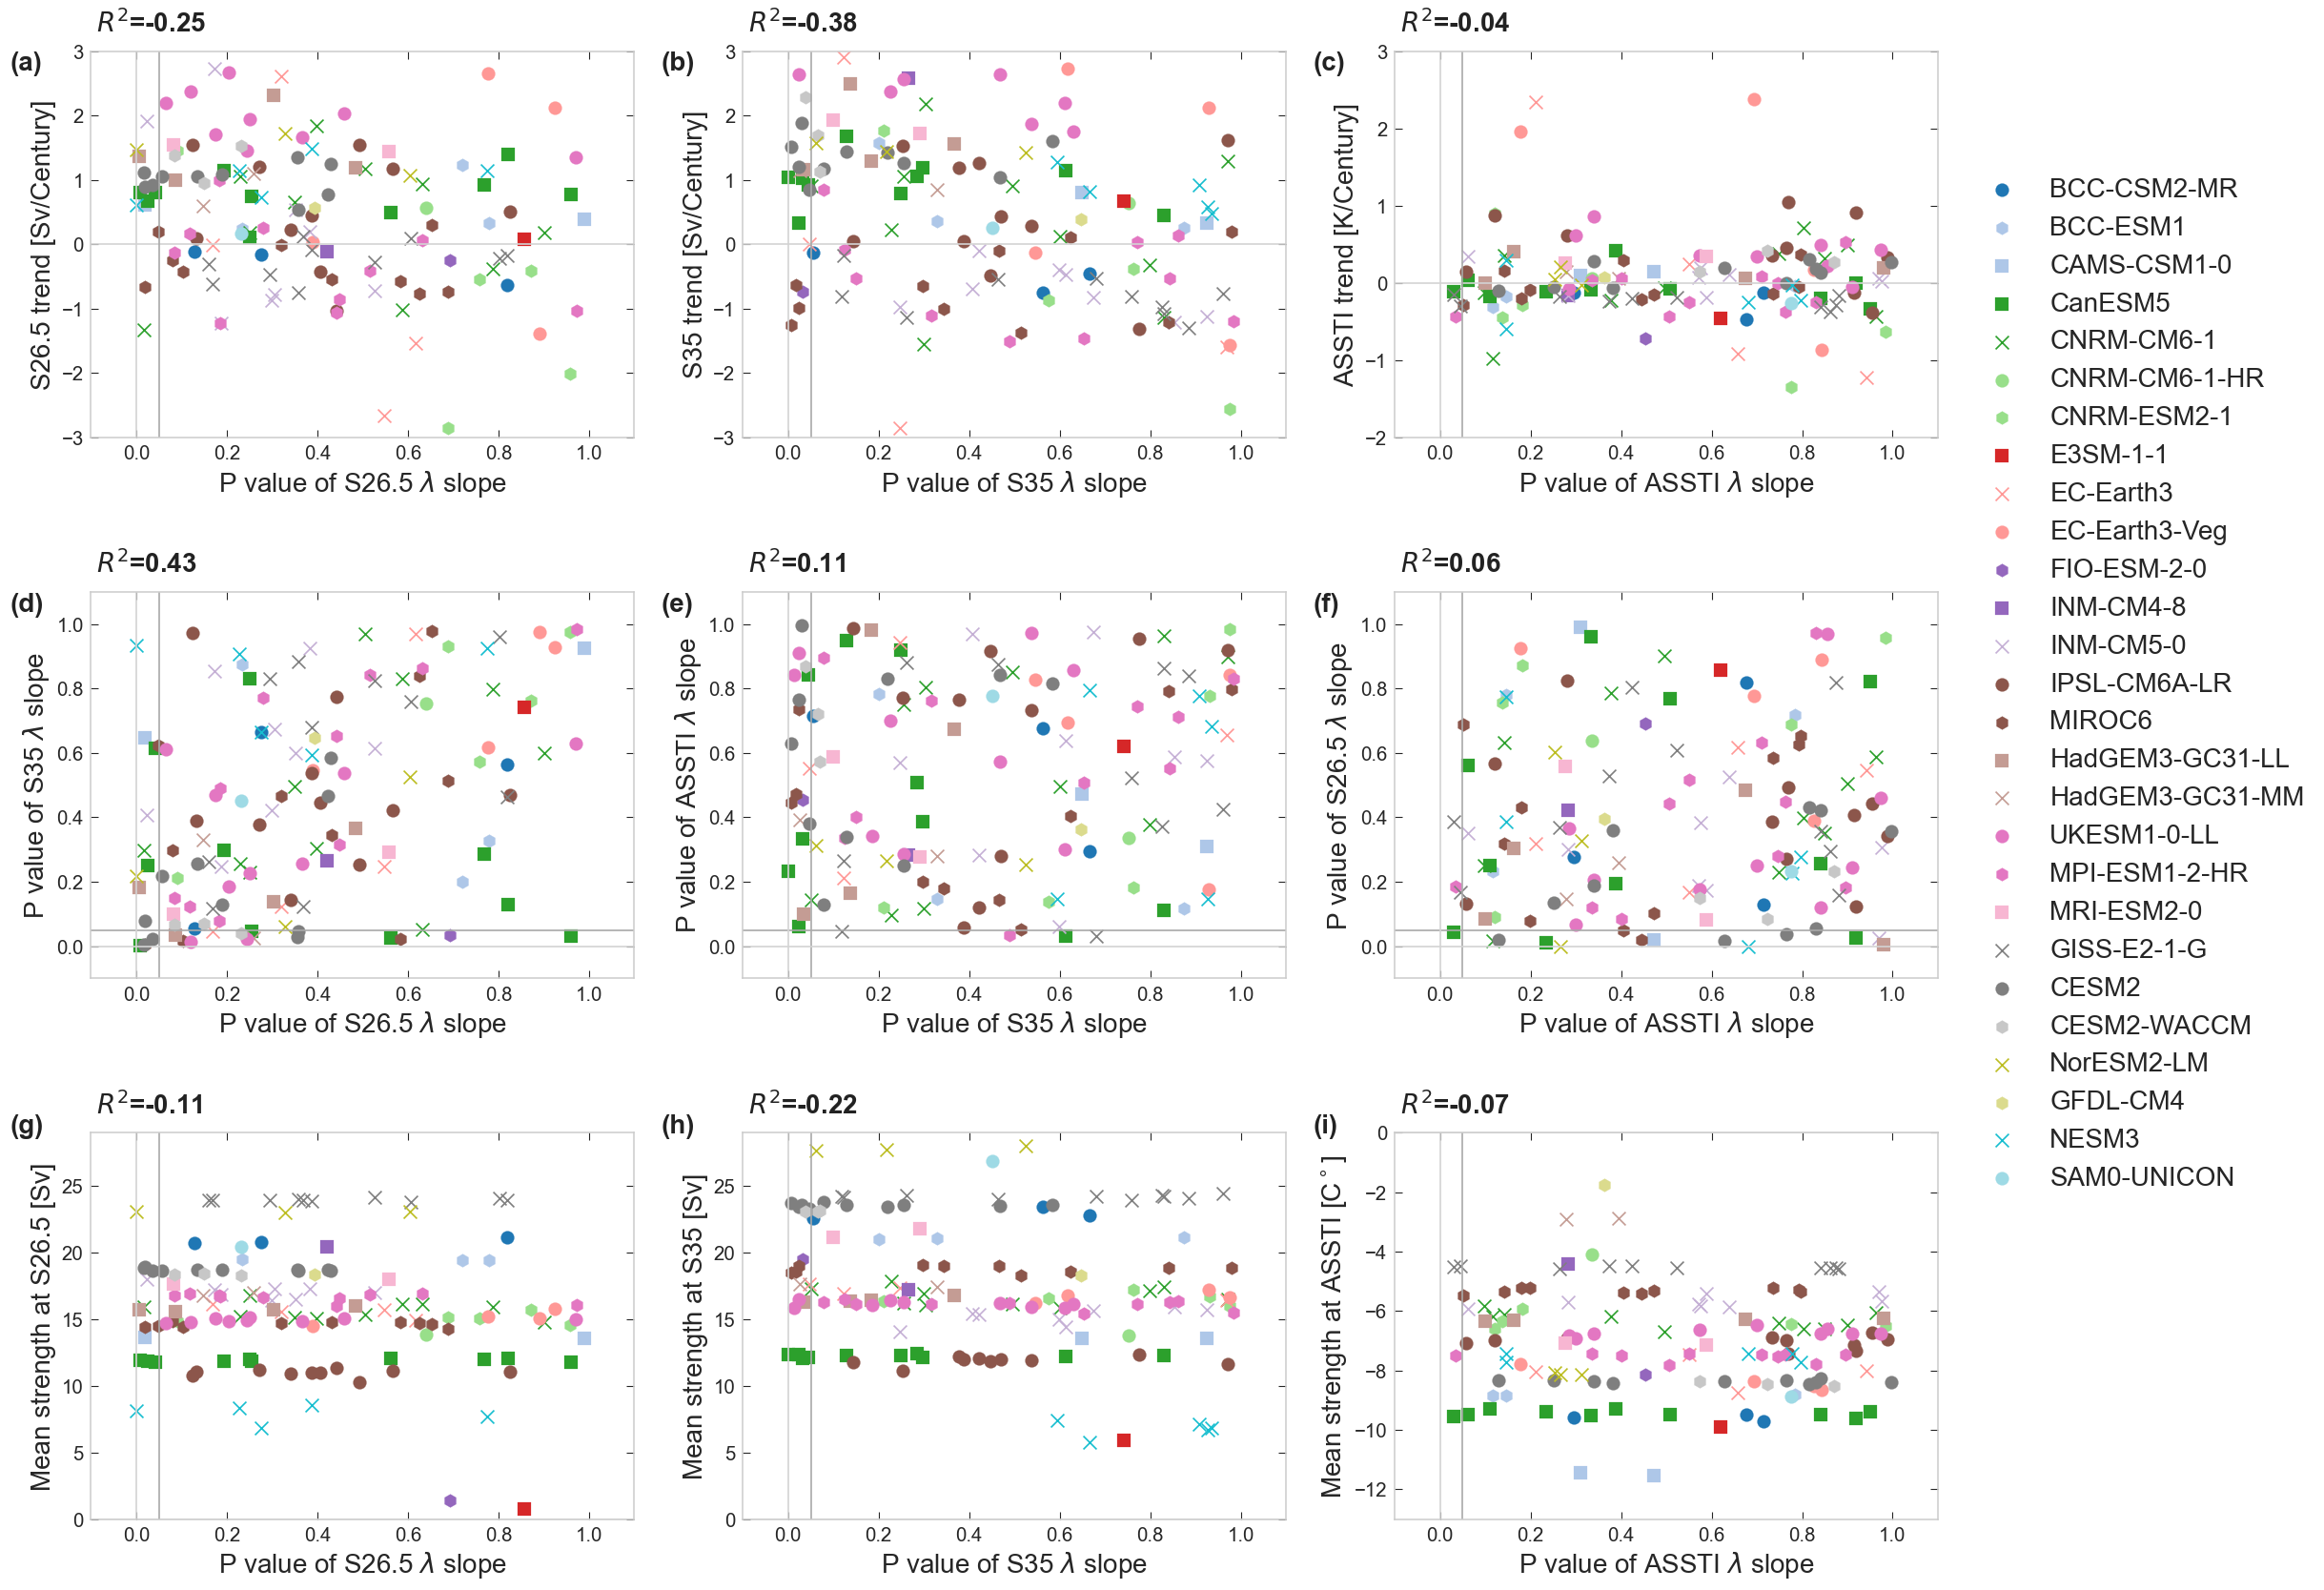

In [50]:
cmap = plt.get_cmap('tab20')
color_list = [cmap(i/34) for i in np.arange(0,34)]
markers = ['x','o','h','s']

fig = plt.figure(figsize=(25,20))
gs = fig.add_gridspec(3, 3)
labelss = ['[Sv/Century]','[Sv/Century]','[K/Century]']
labelss2 = ['[Sv]','[Sv]',r'[C$^\circ$]']
ttls = ['Streamfunction at 26.5N','Streamfunction at 35N','SST Index']
namess = ['S26.5','S35','ASSTI']

trendss = [strn26_trend, strn35_trend, index_trend]
for it, trends in enumerate(trendss):
    ax = fig.add_subplot(gs[0,it])
    x, y = ppvs[it].values,trends
    for im, mod in enumerate(models):
        n_tot = np.count_nonzero(~np.isnan(strn35.sel(models=mod).values))
        if n_tot!=0:
            marker = markers[im%4]
            col = color_list[im]
            plt.scatter(x[im],y[im],color=col,label=mod,marker=marker,s=100)
    r, p = get_corr(x.ravel(),y.ravel())
    ax.text(0.01,1.05,r'$R^2$={:.2f}'.format(r),transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')
    ax.set_ylabel('{} trend {}'.format(namess[it],labelss[it]),fontsize=20)
    ax.set_xlabel(r'P value of {} $\lambda$ slope'.format(namess[it]),fontsize=20)
    ax.hlines(0,-0.1,2,color='lightgrey',alpha=1)
    ax.vlines(0,-4,4,color='lightgrey',alpha=1)
    ax.vlines(0.05,-4,4,color='darkgrey',alpha=1)
    ax.set_xlim(-0.1,1.1)
    if it!=2:
        ax.set_ylim(-3,3)
    else:
        ax.set_ylim(-2,3)
    ax.text(-0.15,0.95,labels[it],transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')
    
for it, name in enumerate(namess):
    ax = fig.add_subplot(gs[1,it])
    x, y = ppvs[it%3].values, ppvs[(it+1)%3].values
    for im, mod in enumerate(models):
        n_tot = np.count_nonzero(~np.isnan(strn35.sel(models=mod).values))
        if n_tot!=0:
            marker = markers[im%4]
            col = color_list[im]
            plt.scatter(x[im],y[im],color=col,label=mod,marker=marker,s=100)
    r, p = get_corr(x.ravel(),y.ravel())
    ax.text(0.01,1.05,r'$R^2$={:.2f}'.format(r),transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')
    ax.set_xlabel(r'P value of {} $\lambda$ slope'.format(namess[it%3]),fontsize=20)
    ax.set_ylabel(r'P value of {} $\lambda$ slope'.format(namess[(it+1)%3]),fontsize=20)
    ax.hlines(0.05,-0.1,2,color='darkgrey',alpha=1)
    ax.vlines(0.05,-0.1,2,color='darkgrey',alpha=1)
    ax.hlines(0,-0.1,2,color='lightgrey',alpha=1)
    ax.vlines(0,-0.1,2,color='lightgrey',alpha=1)
    ax.set_ylim(-0.1,1.1)
    ax.set_xlim(-0.1,1.1)
    ax.text(-0.15,0.95,labels[it+3],transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')

meanss = [strn26.mean(dim='time'),strn35.mean(dim='time'),index.mean(dim='time')]    

for it, means in enumerate(meanss):
    ax = fig.add_subplot(gs[2,it])
    x, y = ppvs[it].values, means.values
    for im, mod in enumerate(models):
        n_tot = np.count_nonzero(~np.isnan(strn35.sel(models=mod).values))
        if n_tot!=0:
            marker = markers[im%4]
            col = color_list[im]
            plt.scatter(x[im],y[im],color=col,label=mod,marker=marker,s=100)
    r, p = get_corr(x.ravel(),y.ravel())
    ax.text(0.01,1.05,r'$R^2$={:.2f}'.format(r),transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')
    ax.set_xlabel(r'P value of {} $\lambda$ slope'.format(namess[it]),fontsize=20)
    ax.set_ylabel(r'Mean strength at {} {}'.format(namess[it],labelss2[it]),fontsize=20)
    ax.hlines(0,-0.1,2,color='lightgrey',alpha=1)
    ax.vlines(0,-30,30,color='lightgrey',alpha=1)
    ax.vlines(0.05,-30,30,color='darkgrey',alpha=1)
    if it==2:
        ax.set_ylim(-13,0)
    else:
        ax.set_ylim(0,29)
    ax.set_xlim(-0.1,1.1)
    ax.text(-0.15,1,labels[it+6],transform=ax.transAxes,color='k',fontsize=20,fontweight='bold')
#     ax.set_title(ttls[it])
    
ax.legend(bbox_to_anchor=(1.05, 3.5), loc='upper left', borderaxespad=0., fontsize=20,fancybox=False,frameon=False,ncol=1)

fig.subplots_adjust(hspace=0.4)
plt.show()
